<a href="https://colab.research.google.com/github/thalanki-shanmukha-sai/fitness-lifestyle-prediction/blob/main/Fitness_Lifestyle_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

This ensures that all necessary libraries are available.

Load DataSet

In [3]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/thalanki-shanmukha-sai/fitness-lifestyle-prediction/refs/heads/main/innovize_final_ml.csv")
df.head()

,phy_fitness,diet_pref,act_level,sleep_hrs,mindfulness,career,gender,daily_avg_steps,daily_avg_calories,is_healthy
0,3.0,Vegan,Sedentary,7,10,Artist,1.0,2020.0,1831.0,0
1,4.0,Vegan,Lightly Active,7,1,Teacher,0.0,5154.0,2190.0,0
2,8.0,Vegetarian,Active,8,10,Freelancer,1.0,12363.0,2297.0,1
3,2.0,Pescatarian,Sedentary,8,7,Doctor,0.0,1664.0,1943.0,0
4,9.0,Pescatarian,Highly Active,5,7,Business,0.0,17680.0,3527.0,1


This will show the first few rows of the dataset.

Preprocess the Data
Run the preprocessing steps, which:

1.   Handle missing values.
2.   Encode categorical variables.
3.   Scale numerical features.
4.   Split data into training & testing sets.



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop missing values
df_cleaned = df.dropna().copy()  # Use .copy() to create an independent copy

# Encoding categorical variables
label_encoders = {}
categorical_cols = ["diet_pref", "act_level", "career"]

for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned.loc[:, col] = le.fit_transform(df_cleaned[col])  # Use .loc[] to modify safely
    label_encoders[col] = le

# Splitting features and target variable
X = df_cleaned.drop(columns=["is_healthy"])
y = df_cleaned["is_healthy"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Train Machine Learning Models
Run this cell to train SVM and Random Forest:

Algorithms included:
 Support Vector Machine (SVM)
 Random Forest
 K-Nearest Neighbors (KNN)
 Logistic Regression
 Naïve Bayes
 Decision Trees




In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dictionary to store model accuracies
model_accuracies = {}

# 1️ Support Vector Machine (SVM)
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
model_accuracies["SVM"] = accuracy_score(y_test, svm_pred)

# 2️ Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
model_accuracies["Random Forest"] = accuracy_score(y_test, rf_pred)

# 3 K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)  # k=5 by default
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
model_accuracies["KNN"] = accuracy_score(y_test, knn_pred)

# 4️ Logistic Regression
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)
model_accuracies["Logistic Regression"] = accuracy_score(y_test, log_reg_pred)

# 5 Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
model_accuracies["Naïve Bayes"] = accuracy_score(y_test, nb_pred)

# 6 Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
model_accuracies["Decision Tree"] = accuracy_score(y_test, dt_pred)

# Print Model Accuracies
for model, accuracy in model_accuracies.items():
    print(f"{model} Accuracy: {accuracy:.4f}")


SVM Accuracy: 0.9874
Random Forest Accuracy: 0.9790
KNN Accuracy: 0.9573
Logistic Regression Accuracy: 0.9958
Naïve Bayes Accuracy: 0.8391
Decision Tree Accuracy: 0.9723


In [10]:
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

In [8]:
# SVM Hyperparameters
svm_params = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear", "rbf", "poly"],  # Different kernel types
    "gamma": ["scale", "auto"]  # Kernel coefficient
}

# Random Forest Hyperparameters
rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [None, 10, 20],  # Tree depth
    "min_samples_split": [2, 5, 10]  # Minimum samples required for splitting
}

# Logistic Regression Hyperparameters
log_reg_params = {
    "C": [0.01, 0.1, 1, 10],  # Regularization strength
    "solver": ["lbfgs", "liblinear"]  # Solvers for optimization
}


In [11]:
# Initialize models
svm_model = SVC(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Perform GridSearchCV
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring="accuracy", n_jobs=-1)
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring="accuracy", n_jobs=-1)
log_reg_grid = GridSearchCV(log_reg_model, log_reg_params, cv=5, scoring="accuracy", n_jobs=-1)

# Fit models
svm_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)
log_reg_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [12]:
# Best models after tuning
best_svm = svm_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_log_reg = log_reg_grid.best_estimator_

# Perform 5-Fold Cross-Validation
svm_cv_scores = cross_val_score(best_svm, X_train, y_train, cv=5, scoring="accuracy")
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="accuracy")
log_reg_cv_scores = cross_val_score(best_log_reg, X_train, y_train, cv=5, scoring="accuracy")

# Print cross-validation results
print(f"Best SVM Accuracy (Cross-Validation): {np.mean(svm_cv_scores):.4f}")
print(f"Best Random Forest Accuracy (Cross-Validation): {np.mean(rf_cv_scores):.4f}")
print(f"Best Logistic Regression Accuracy (Cross-Validation): {np.mean(log_reg_cv_scores):.4f}")


Best SVM Accuracy (Cross-Validation): 0.9966
Best Random Forest Accuracy (Cross-Validation): 0.9813
Best Logistic Regression Accuracy (Cross-Validation): 0.9979


In [13]:
# Predict with best models
svm_pred = best_svm.predict(X_test)
rf_pred = best_rf.predict(X_test)
log_reg_pred = best_log_reg.predict(X_test)

# Compute final accuracy
svm_final_acc = accuracy_score(y_test, svm_pred)
rf_final_acc = accuracy_score(y_test, rf_pred)
log_reg_final_acc = accuracy_score(y_test, log_reg_pred)

# Print Final Results
print(f"Final SVM Accuracy: {svm_final_acc:.4f}")
print(f"Final Random Forest Accuracy: {rf_final_acc:.4f}")
print(f"Final Logistic Regression Accuracy: {log_reg_final_acc:.4f}")


Final SVM Accuracy: 0.9992
Final Random Forest Accuracy: 0.9790
Final Logistic Regression Accuracy: 0.9992


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Reduce X_train and X_test to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convert test labels to numpy array for plotting
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)


In [15]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02  # Step size in the mesh

    # Create a mesh grid for background
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class for each grid point
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["red", "blue"]))

    # Scatter plot of training data
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(["darkred", "darkblue"]), edgecolor="k")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()


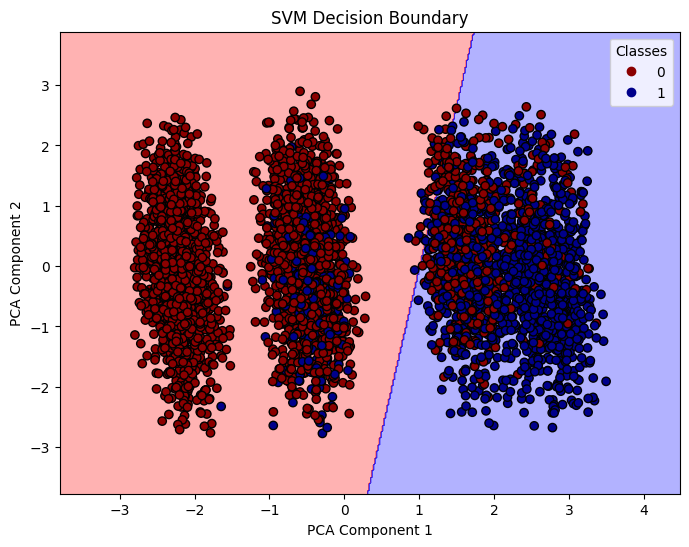

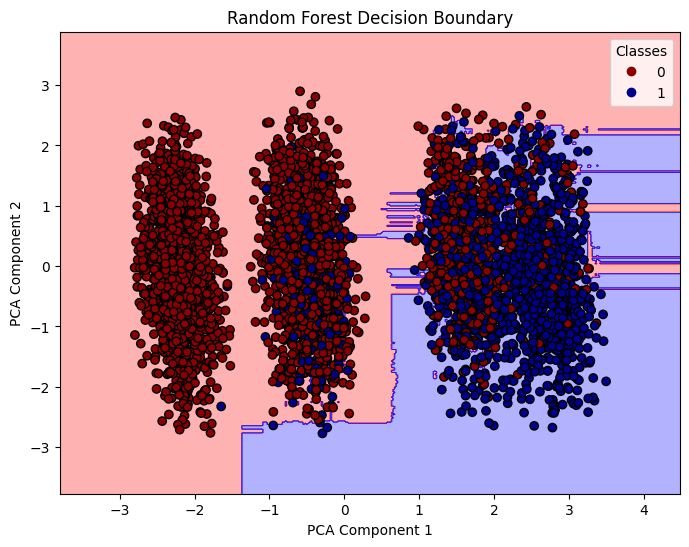

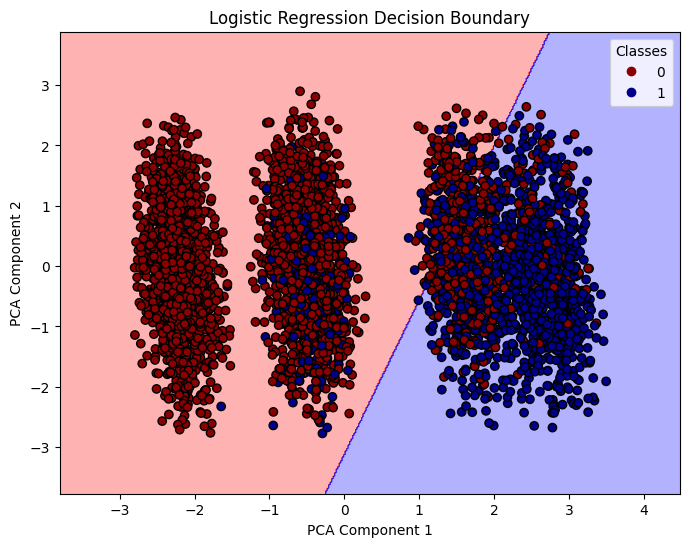

In [16]:
# Train models on PCA-reduced training data
best_svm.fit(X_train_pca, y_train)
best_rf.fit(X_train_pca, y_train)
best_log_reg.fit(X_train_pca, y_train)

# Plot decision boundaries
plot_decision_boundary(best_svm, X_train_pca, y_train_np, "SVM Decision Boundary")
plot_decision_boundary(best_rf, X_train_pca, y_train_np, "Random Forest Decision Boundary")
plot_decision_boundary(best_log_reg, X_train_pca, y_train_np, "Logistic Regression Decision Boundary")


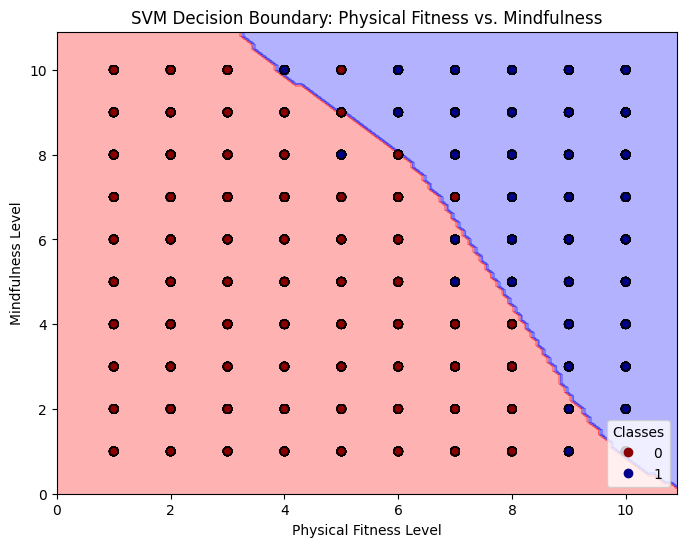

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# Select two features: phy_fitness and mindfulness
X_selected = df_cleaned[['phy_fitness', 'mindfulness']].values
y_selected = df_cleaned["is_healthy"].values

# Train an SVM model
svm_model_2d = SVC(kernel="rbf", random_state=42)
svm_model_2d.fit(X_selected, y_selected)

# Define function to plot decision boundary
def plot_decision_boundary_2d(model, X, y, title):
    h = 0.1  # Step size for mesh grid

    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["red", "blue"]))

    # Scatter plot of data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(["darkred", "darkblue"]), edgecolor="k")

    plt.xlabel("Physical Fitness Level")
    plt.ylabel("Mindfulness Level")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# Plot decision boundary for selected features
plot_decision_boundary_2d(svm_model_2d, X_selected, y_selected, "SVM Decision Boundary: Physical Fitness vs. Mindfulness")


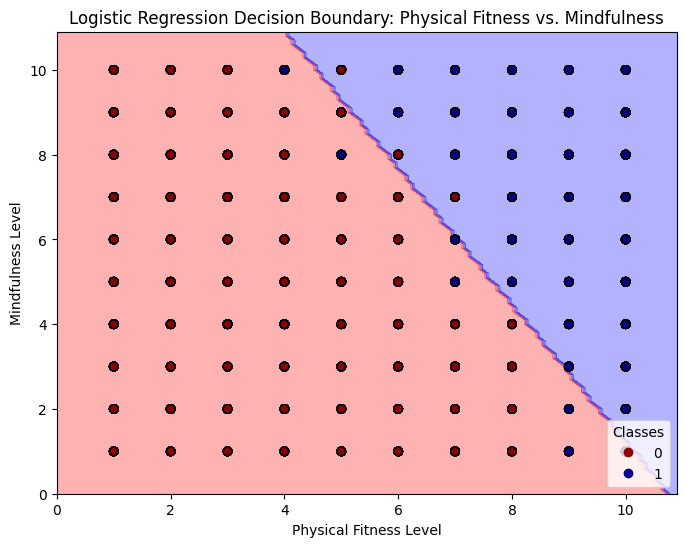

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# Select two features: phy_fitness and mindfulness
X_selected = df_cleaned[['phy_fitness', 'mindfulness']].values
y_selected = df_cleaned["is_healthy"].values

# Train a Logistic Regression model
log_reg_2d = LogisticRegression()
log_reg_2d.fit(X_selected, y_selected)

# Define function to plot decision boundary
def plot_decision_boundary_2d(model, X, y, title):
    h = 0.1  # Step size for mesh grid

    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["red", "blue"]))

    # Scatter plot of data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(["darkred", "darkblue"]), edgecolor="k")

    plt.xlabel("Physical Fitness Level")
    plt.ylabel("Mindfulness Level")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# Plot decision boundary for selected features
plot_decision_boundary_2d(log_reg_2d, X_selected, y_selected, "Logistic Regression Decision Boundary: Physical Fitness vs. Mindfulness")


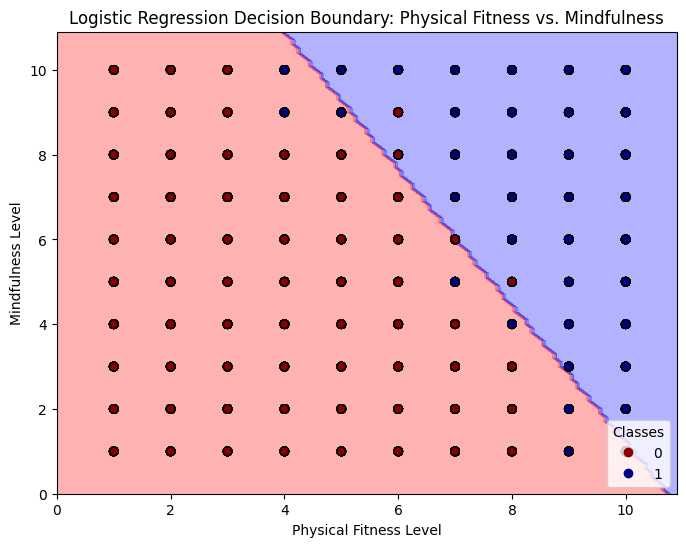

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

# Select two features: phy_fitness and mindfulness
X_selected = df_cleaned[['phy_fitness', 'mindfulness']].values
y_selected = df_cleaned["is_healthy"].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)

# Train a Logistic Regression model
log_reg_2d = LogisticRegression()
log_reg_2d.fit(X_train, y_train)

# Define function to plot decision boundary
def plot_decision_boundary_2d(model, X, y, title):
    h = 0.1  # Step size for mesh grid

    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["red", "blue"]))

    # Scatter plot of data points (Train Data)
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(["darkred", "darkblue"]), edgecolor="k")

    plt.xlabel("Physical Fitness Level")
    plt.ylabel("Mindfulness Level")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# Plot decision boundary for selected features (Using Training Data)
plot_decision_boundary_2d(log_reg_2d, X_train, y_train, "Logistic Regression Decision Boundary: Physical Fitness vs. Mindfulness")


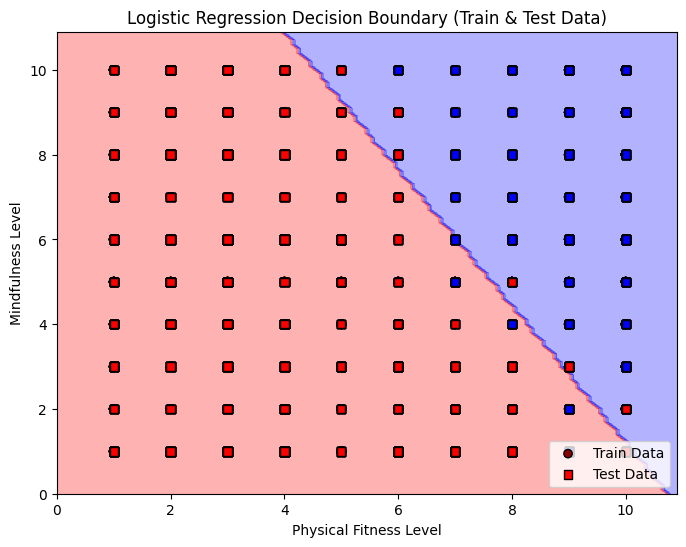

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

# Select two features: phy_fitness and mindfulness
X_selected = df_cleaned[['phy_fitness', 'mindfulness']].values
y_selected = df_cleaned["is_healthy"].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)

# Train a Logistic Regression model
log_reg_2d = LogisticRegression()
log_reg_2d.fit(X_train, y_train)

# Function to plot decision boundary with train & test points
def plot_decision_boundary_2d(model, X_train, y_train, X_test, y_test, title):
    h = 0.1  # Step size for mesh grid

    # Create a mesh grid
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["red", "blue"]))

    # Scatter plot of train and test data
    train_scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(["darkred", "darkblue"]), marker='o', edgecolor="k", label="Train Data")
    test_scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=ListedColormap(["red", "blue"]), marker='s', edgecolor="k", label="Test Data")

    plt.xlabel("Physical Fitness Level")
    plt.ylabel("Mindfulness Level")
    plt.title(title)
    plt.legend()
    plt.show()

# Plot decision boundary for train & test data
plot_decision_boundary_2d(log_reg_2d, X_train, y_train, X_test, y_test, "Logistic Regression Decision Boundary (Train & Test Data)")
